## independent test plot

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

eval_cv_dir = "experiment/independent_test/eval_cv"
task_dir = {
    "cancer_specific": ["COAD", "LAML", "LUAD"],
    # "mix": ["mix"]
}
models = ["transformer", "geneformer"]
metrics = ["ndcg@10","ndcg@20","ndcg@30","ndcg@50","ndcg@100"]

In [ ]:
eval_cv_dir = "experiment/independent_test/eval_cv"
task_dir = {
    "cancer_specific": ["COAD", "LAML", "LUAD"],
    "mix": ["mix"]
}
models = ["transformer", "geneformer"]
metrics = ["ndcg@10","ndcg@20","ndcg@30","ndcg@50","ndcg@100"]

plot_data = []

for task, dirs in task_dir.items():
    for dir in dirs:
        for f in os.listdir(os.path.join(eval_cv_dir, dir)):
            for model in models:
                if model in f and "binary" not in f and "OV" not in f and "COAD" in f: # COAD 
                # if model in f and "binary" not in f and "OV" not in f and "viability" in f: # LUAD 
                    df = pd.read_csv(os.path.join(eval_cv_dir, dir, f))
                    print(os.path.join(eval_cv_dir, dir, f))
                    for i in range(len(df)):
                        plot_data_dict = {
                            "task": task,
                            "model": model if model=="geneformer" else "SLformer"
                        }
                        for m in metrics:
                            plot_data_dict[m] = df.iloc[i][m]
                        plot_data.append(plot_data_dict)
TASK = "cancer_specific"
plot_data = pd.DataFrame(plot_data)
df_list_new = []
for metric in ["ndcg@10","ndcg@20","ndcg@30","ndcg@50","ndcg@100"]:
    df_1m = plot_data[['task', 'model', metric]].copy()
    df_1m.columns = ['task', 'model', 'ndcg_score']
    df_1m['metric'] = metric
    df_list_new.append(df_1m)
plot_data_sep = pd.concat(df_list_new, ignore_index=True)
plot_data_sep_task = plot_data_sep[plot_data_sep['task']==TASK]
plot_data_sep_task['Model'] = plot_data_sep_task['model'].map({
    'geneformer': 'Geneformer Probing',
    'SLformer': 'SLformer'
})
plot_data_sep_task['metric'] = plot_data_sep_task['metric'].str.upper()
# plot_data_sep_task

experiment/independent_test/eval_cv/COAD/primpartner_study3_COAD_geneformer.csv
experiment/independent_test/eval_cv/COAD/primpartner_study3_COAD_transformer.csv


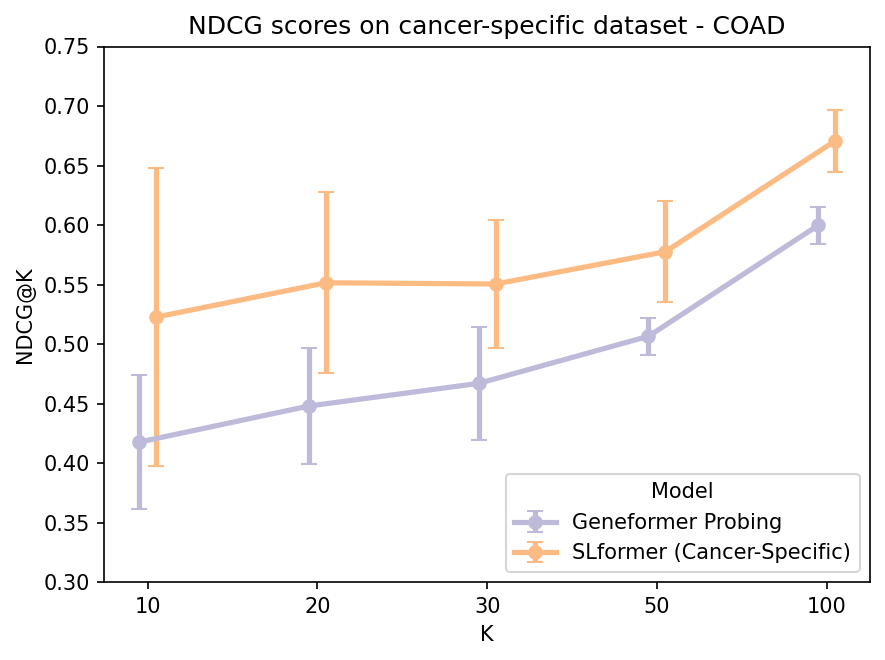

In [ ]:
summary = plot_data_sep_task.groupby(['Model', 'metric'])['ndcg_score'].agg(['mean', 'std']).reset_index()

# Sort metrics by the original order
metrics_order = ["NDCG@10", "NDCG@20", "NDCG@30", "NDCG@50", "NDCG@100"]
summary['metric'] = pd.Categorical(summary['metric'], categories=metrics_order, ordered=True)
summary = summary.sort_values(['Model', 'metric'])
# print(summary)

# Get positions
x_pos = np.arange(len(metrics_order))
offset = 0.05

# Separate data
cancer_specific = summary[summary['Model'] == 'Geneformer Probing']
mix_cancer = summary[summary['Model'] == 'SLformer']

# Plot
plt.figure(figsize=(6, 4.5), dpi=150)

# cancer_specific: left
plt.errorbar(x_pos - offset, cancer_specific['mean'], yerr=cancer_specific['std'],
             fmt='o-', color='#bebada', capsize=4, label='Geneformer Probing', linewidth=2.5)

# mix_cancer: right
plt.errorbar(x_pos + offset, mix_cancer['mean'], yerr=mix_cancer['std'],
             fmt='o-', color='#fdbb84', capsize=4, label='SLformer (Cancer-Specific)', linewidth=2.5)

# Rename legend labels and set location
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['Geneformer Probing', 'SLformer (Cancer-Specific)']
plt.legend(handles, new_labels, title='Model', fontsize=10, loc='lower right')

# Customized
plt.xticks(ticks=x_pos, labels=['10', '20', '30', '50', '100'])
plt.xlabel("K")
plt.ylabel("NDCG@K")
plt.title(f'NDCG scores on cancer-specific dataset - COAD') 

# plt.ylim(0.40, 0.71) # LUAD 
plt.ylim(0.30, 0.75) # COAD 

plt.tight_layout()
plt.show()


experiment/independent_test/eval_cv/mix/paralog_study1_score_geneformer.csv
experiment/independent_test/eval_cv/mix/paralog_study1_score_transformer.csv


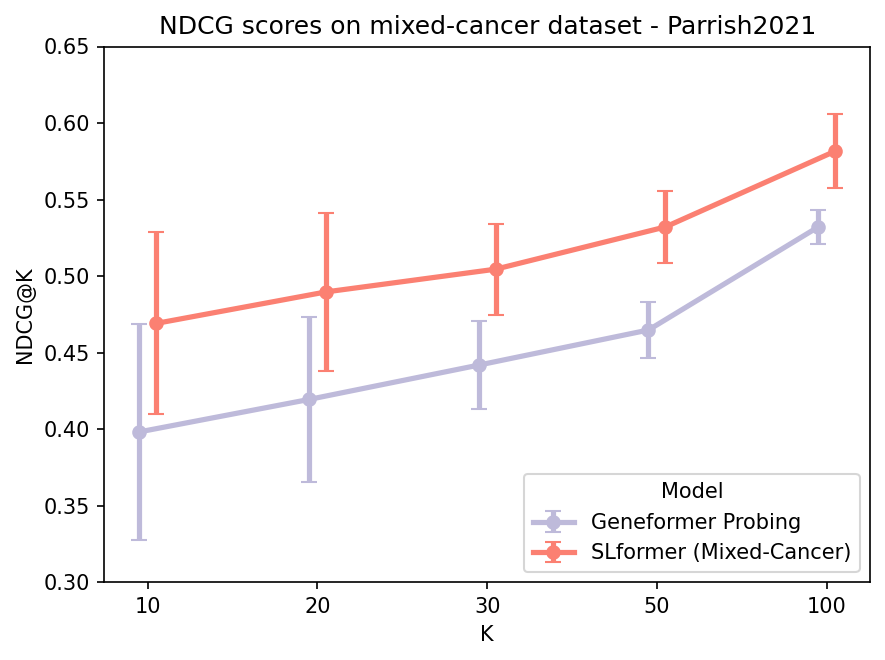

In [ ]:
### mixed-caner
eval_cv_dir = "experiment/independent_test/eval_cv"
task_dir = {
    "cancer_specific": ["COAD", "LAML", "LUAD"],
    "mix": ["mix"]
}
models = ["transformer", "geneformer"]
metrics = ["ndcg@10","ndcg@20","ndcg@30","ndcg@50","ndcg@100"]

plot_data = []

for task, dirs in task_dir.items():
    for dir in dirs:
        for f in os.listdir(os.path.join(eval_cv_dir, dir)):
            for model in models:
                if model in f and "binary" not in f and "OV" not in f and "paralog_study1_score" in f: # mix Parrish2021 
                # if model in f and "binary" not in f and "OV" not in f and "paralog_study2_score" in f: # mix Dede2020 
                    df = pd.read_csv(os.path.join(eval_cv_dir, dir, f))
                    print(os.path.join(eval_cv_dir, dir, f))
                    for i in range(len(df)):
                        plot_data_dict = {
                            "task": task,
                            "model": model if model=="geneformer" else "SLformer"
                        }
                        for m in metrics:
                            plot_data_dict[m] = df.iloc[i][m]
                        plot_data.append(plot_data_dict)

plot_data = pd.DataFrame(plot_data)
df_list_new = []
for metric in ["ndcg@10","ndcg@20","ndcg@30","ndcg@50","ndcg@100"]:
    df_1m = plot_data[['task', 'model', metric]].copy()
    df_1m.columns = ['task', 'model', 'ndcg_score']
    df_1m['metric'] = metric
    df_list_new.append(df_1m)
plot_data_sep = pd.concat(df_list_new, ignore_index=True)
TASK = "mix"
plot_data_sep_task = plot_data_sep[plot_data_sep['task']==TASK]
plot_data_sep_task['Model'] = plot_data_sep_task['model'].map({
    'geneformer': 'Geneformer Probing',
    'SLformer': 'SLformer'
})
plot_data_sep_task['metric'] = plot_data_sep_task['metric'].str.upper()
# plot_data_sep_task

summary = plot_data_sep_task.groupby(['Model', 'metric'])['ndcg_score'].agg(['mean', 'std']).reset_index()

# Sort metrics by the original order
metrics_order = ["NDCG@10", "NDCG@20", "NDCG@30", "NDCG@50", "NDCG@100"]
summary['metric'] = pd.Categorical(summary['metric'], categories=metrics_order, ordered=True)
summary = summary.sort_values(['Model', 'metric'])
# print(summary)

# Get positions
x_pos = np.arange(len(metrics_order))
offset = 0.05

# Separate data
cancer_specific = summary[summary['Model'] == 'Geneformer Probing']
mix_cancer = summary[summary['Model'] == 'SLformer']

# Plot
plt.figure(figsize=(6, 4.5), dpi=150)

# cancer_specific: left
plt.errorbar(x_pos - offset, cancer_specific['mean'], yerr=cancer_specific['std'],
             fmt='o-', color='#bebada', capsize=4, label='Geneformer Probing', linewidth=2.5)

# mix_cancer: right
plt.errorbar(x_pos + offset, mix_cancer['mean'], yerr=mix_cancer['std'],
             fmt='o-', color='#fb8072', capsize=4, label='SLformer (Mixed-Cancer)', linewidth=2.5)

# Rename legend labels and set location
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['Geneformer Probing', 'SLformer (Mixed-Cancer)']
plt.legend(handles, new_labels, title='Model', fontsize=10, loc='lower right')

# Customized
plt.xticks(ticks=x_pos, labels=['10', '20', '30', '50', '100'])
plt.xlabel("K")
plt.ylabel("NDCG@K")
plt.title(f'NDCG scores on mixed-cancer dataset - Parrish2021') 

plt.ylim(0.30, 0.65) # Parrish2021 
# plt.ylim(0.35, 0.70) # Dede2020 

plt.tight_layout()
plt.show()
